In [2]:
import pandas as pd

# original untouched data
df_all = pd.read_csv("pqm_extract.csv")

# keep only plans with a slash in PlanId
df = df_all[
    df_all["PlanId"]
    .fillna("")
    .str.contains("/", regex=False)
].copy()

print(f"Original rows : {len(df_all):,}")
print(f"Rows with '/' : {len(df):,}")

df.head()

Original rows : 3,190
Rows with '/' : 3,110


,PatientId,CourseId,PlanId,StructureId,MetricId,Value,Unit,Status,Error
0,99DART-HN_1,Session 1,IM111/SCH0101,PTV2,V95% PTV2,99.519,%,Ok,NaN
1,99DART-HN_1,Session 1,IM111/SCH0101,PTV3,V95% PTV3,99.785,%,Ok,NaN
2,99DART-HN_1,Session 1,IM111/SCH0101,PTV2-PTV1,V107%/V64.2Gy PTV2-PTV1,20.002,%,Ok,NaN
3,99DART-HN_1,Session 1,IM111/SCH0101,PTV3-PTV2,V107%/V53.5Gy PTV3-PTV2,0.178,%,Ok,NaN
4,99DART-HN_1,Session 1,IM111/SCH0101,PTV1,D1.8cm3 PTV1,69.959,Gy,Ok,NaN


In [16]:
import pandas as pd

summary = {
    "Patients": df["PatientId"].nunique(),
    "Sessions": df[["PatientId", "CourseId"]].drop_duplicates().shape[0],
    "Plans": df[["PatientId", "CourseId", "PlanId"]].drop_duplicates().shape[0],
    "Metrics": df["MetricId"].nunique(),
    "Rows": len(df),
    "PlansPerSession_Min": (
        df[["PatientId", "CourseId", "PlanId"]]
        .drop_duplicates()
        .groupby(["PatientId", "CourseId"])
        .size()
        .min()
    ),
    "PlansPerSession_Max": (
        df[["PatientId", "CourseId", "PlanId"]]
        .drop_duplicates()
        .groupby(["PatientId", "CourseId"])
        .size()
        .max()
    ),
}

display(pd.DataFrame([summary]))

print("\nMetrics:")
display(df["MetricId"].value_counts())

print("\nSessions per patient:")
display(
    df[["PatientId", "CourseId"]]
    .drop_duplicates()
    .groupby("PatientId")
    .size()
    .rename("SessionCount")
    .sort_index()
)

,Patients,Sessions,Plans,Metrics,Rows,PlansPerSession_Min,PlansPerSession_Max
0,10,311,622,5,3110,2,2



Metrics:


MetricId
V95% PTV2                  622
V95% PTV3                  622
V107%/V64.2Gy PTV2-PTV1    622
V107%/V53.5Gy PTV3-PTV2    622
D1.8cm3 PTV1               622
Name: count, dtype: int64


Sessions per patient:


PatientId
99DART-HN_1     34
99DART-HN_10    23
99DART-HN_2     34
99DART-HN_3     34
99DART-HN_4     34
99DART-HN_5     34
99DART-HN_6     34
99DART-HN_7     17
99DART-HN_8     33
99DART-HN_9     34
Name: SessionCount, dtype: int64

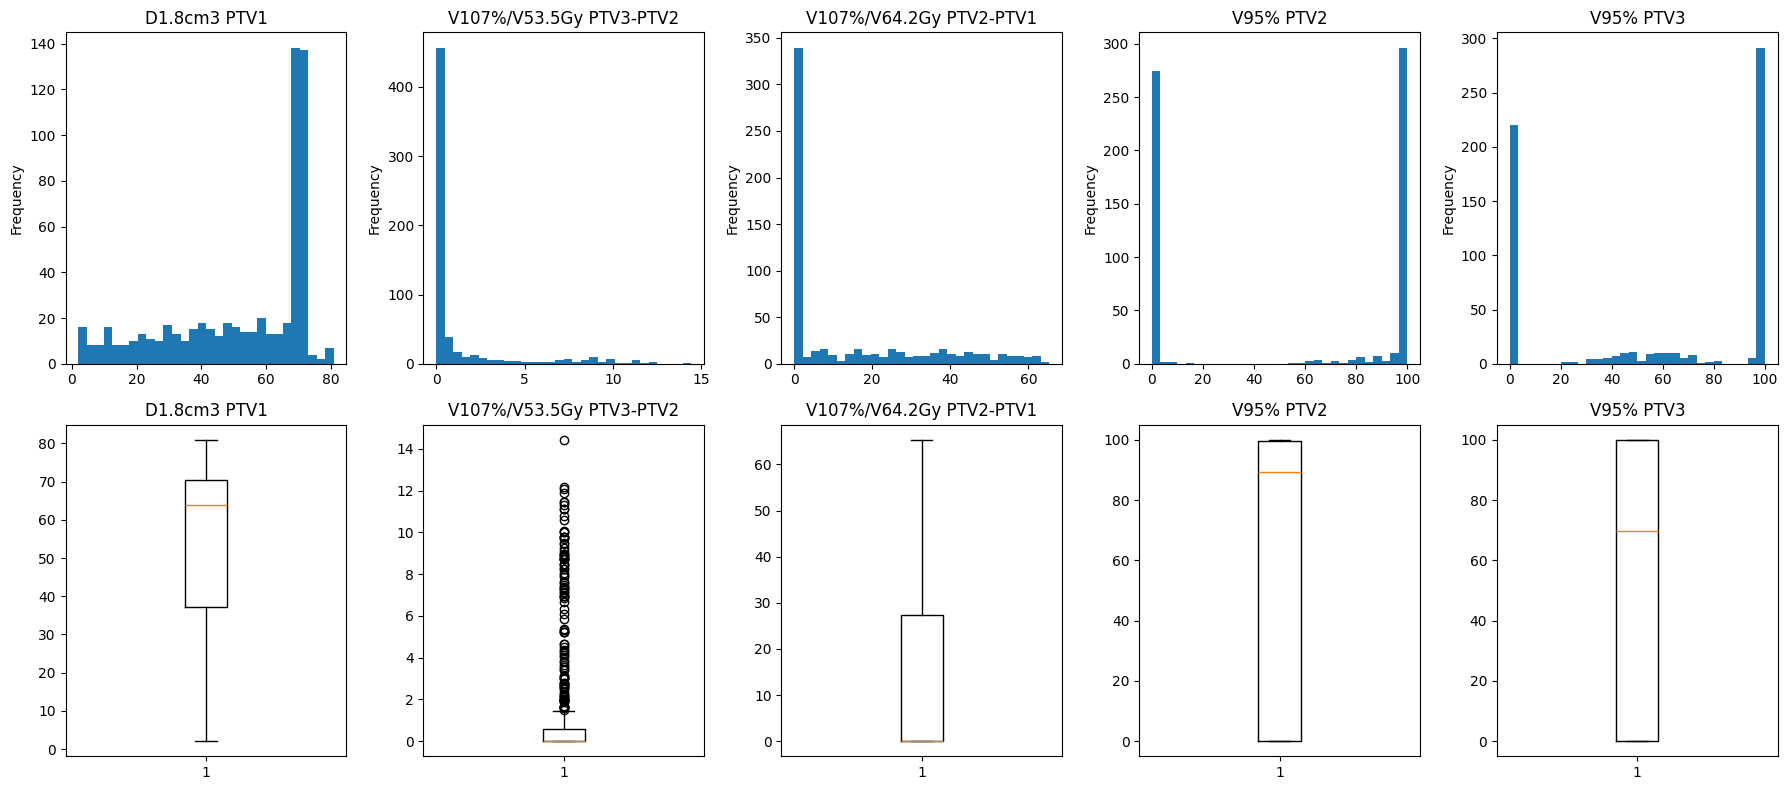

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, metric in enumerate(sorted(df["MetricId"].unique())):
    values = pd.to_numeric(
        df.loc[df["MetricId"] == metric, "Value"],
        errors="coerce"
    )

    values.plot.hist(
        bins=30,
        ax=axes[0, i],
        title=metric
    )

    axes[1, i].boxplot(values.dropna(), vert=True)
    axes[1, i].set_title(metric)

plt.tight_layout()
plt.show()

In [23]:
(
    df[df["MetricId"] == "V95% PTV2"]
    .assign(Value=lambda x: pd.to_numeric(x["Value"]))
    .sort_values("Value")
    [["PatientId","CourseId","PlanId","MetricId","Value"]]
    .head(50)
)


,PatientId,CourseId,PlanId,MetricId,Value
2005,99DART-HN_6,Session 33,IM122/SCH3303,V95% PTV2,0.0
1930,99DART-HN_6,Session 27,IM122/SCH2704,V95% PTV2,0.0
1925,99DART-HN_6,Session 26,IM122/ADP2604,V95% PTV2,0.0
1920,99DART-HN_6,Session 26,IM122/SCH2603,V95% PTV2,0.0
1915,99DART-HN_6,Session 25,IM122/SCH2504,V95% PTV2,0.0
2075,99DART-HN_6,Session 9,IM122/SCH0904,V95% PTV2,0.0
2020,99DART-HN_6,Session 34,IM122/SCH3404,V95% PTV2,0.0
2015,99DART-HN_6,Session 34,IM122/ADP3403,V95% PTV2,0.0
2010,99DART-HN_6,Session 33,IM122/ADP3304,V95% PTV2,0.0
1935,99DART-HN_6,Session 27,IM122/ADP2703,V95% PTV2,0.0
